In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

print("Libraries loaded ✅")

Libraries loaded ✅


In [2]:
# ✅ Dataset in the SAME folder as this notebook
df = pd.read_csv("email.csv")

print(f"Shape  : {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape  : (5573, 2)
Columns: ['Category', 'Message']


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
# Auto-detect text & label columns
text_keywords  = ["text", "message", "email", "content", "body", "subject"]
label_keywords = ["label", "spam", "class", "target", "category", "type"]

text_col  = next((c for c in df.columns if c.lower() in text_keywords), None)
label_col = next((c for c in df.columns if c.lower() in label_keywords), None)

# Fallback if column names are different
if text_col is None:
    text_col = df.select_dtypes(include="object").columns[0]
if label_col is None:
    label_col = df.columns[-1]

print(f"Text  column → '{text_col}'")
print(f"Label column → '{label_col}'")

df = df[[text_col, label_col]].dropna()
df.columns = ["text", "label"]

# Normalize labels: spam=1, ham=0
df["label"] = df["label"].astype(str).str.lower().str.strip()
df["label"] = df["label"].map(lambda x: 1 if x in ("spam","1","yes","true") else 0)

print(f"\nClass distribution:\n{df['label'].value_counts().rename({0:'Ham', 1:'Spam'})}")

Text  column → 'Message'
Label column → 'Category'

Class distribution:
label
Ham     4826
Spam     747
Name: count, dtype: int64


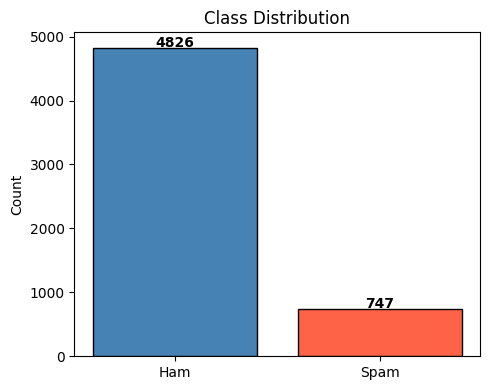

In [4]:
counts = df["label"].value_counts()
plt.figure(figsize=(5, 4))
plt.bar(["Ham", "Spam"], counts.values, color=["steelblue", "tomato"], edgecolor="black")
plt.title("Class Distribution")
plt.ylabel("Count")
for i, v in enumerate(counts.values):
    plt.text(i, v + 5, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Train: 4458 | Test: 1115


In [6]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2),
        lowercase=True
    )),
    ("clf", ComplementNB(alpha=0.1))
])

pipeline.fit(X_train, y_train)
print("Model trained ✅")

Model trained ✅


In [7]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy : {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

cv = cross_val_score(pipeline, X, y, cv=5, scoring="accuracy")
print(f"5-Fold CV: {cv.mean()*100:.2f}% ± {cv.std()*100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

Accuracy : 96.86%
ROC-AUC  : 0.9912
5-Fold CV: 97.27% ± 0.46%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98       966
        Spam       0.83      0.96      0.89       149

    accuracy                           0.97      1115
   macro avg       0.91      0.96      0.94      1115
weighted avg       0.97      0.97      0.97      1115



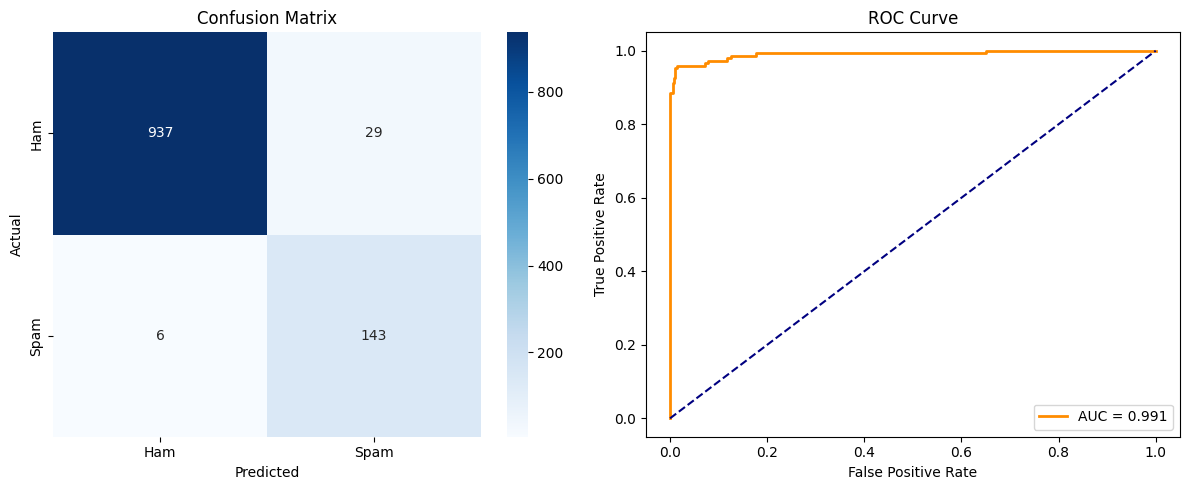

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Ham","Spam"], yticklabels=["Ham","Spam"], ax=axes[0])
axes[0].set_title("Confusion Matrix")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0,1],[0,1],"--", color="navy")
axes[1].set_title("ROC Curve")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
joblib.dump(pipeline, "spam_model.pkl")
print("Model saved as spam_model.pkl ✅")

Model saved as spam_model.pkl ✅


In [11]:
def predict_email(text):
    pred = pipeline.predict([text])[0]
    prob = pipeline.predict_proba([text])[0]
    label = "🚨 SPAM" if pred == 1 else "✅ Ham"
    print(f"Email  : {text[:65]}...")
    print(f"Result : {label}  |  Spam: {prob[1]*100:.1f}%  Ham: {prob[0]*100:.1f}%")
    print("-" * 60)

emails = [
    "Congratulations! You won a FREE iPhone. Click here to claim!!!",
    "Can we reschedule our meeting to 3pm tomorrow?",
    "URGENT: Your bank account is suspended. Verify immediately.",
    "Please review the attached report before the standup.",
]

for e in emails:
    predict_email(e)

Email  : Congratulations! You won a FREE iPhone. Click here to claim!!!...
Result : 🚨 SPAM  |  Spam: 99.7%  Ham: 0.3%
------------------------------------------------------------
Email  : Can we reschedule our meeting to 3pm tomorrow?...
Result : ✅ Ham  |  Spam: 2.0%  Ham: 98.0%
------------------------------------------------------------
Email  : URGENT: Your bank account is suspended. Verify immediately....
Result : 🚨 SPAM  |  Spam: 97.1%  Ham: 2.9%
------------------------------------------------------------
Email  : Please review the attached report before the standup....
Result : ✅ Ham  |  Spam: 23.7%  Ham: 76.3%
------------------------------------------------------------
